# Discretization:

Discretization is the process of converting continuous numerical data into a finite number
of intervals (bins or categories).

In [67]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer

In [69]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [70]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [71]:
# impute the missing values 
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['age'].fillna(df['fare'].median())

In [72]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,22.0,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,38.0,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,26.0,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,35.0,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,35.0,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='age', ylabel='Count'>

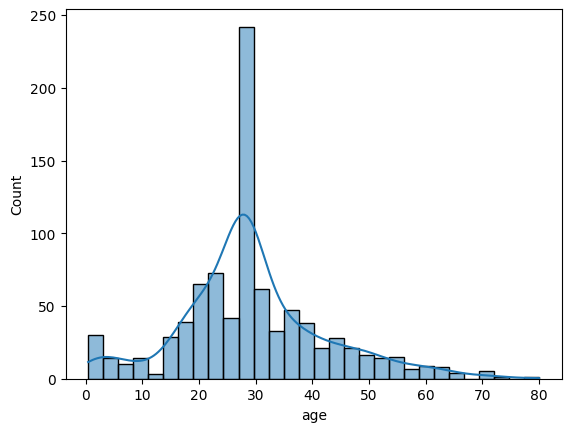

In [73]:
sns.histplot(df['age'], kde=True)

In [74]:
# age discretization
age_discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
df['age_bin'] = age_discretizer.fit_transform(df[['age']])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_bin
0,0,3,male,22.0,1,0,22.0,S,Third,man,True,NaN,Southampton,no,False,1.0
1,1,1,female,38.0,1,0,38.0,C,First,woman,False,C,Cherbourg,yes,False,2.0
2,1,3,female,26.0,0,0,26.0,S,Third,woman,False,NaN,Southampton,yes,True,1.0
3,1,1,female,35.0,1,0,35.0,S,First,woman,False,C,Southampton,yes,False,2.0
4,0,3,male,35.0,0,0,35.0,S,Third,man,True,NaN,Southampton,no,True,2.0


<Axes: xlabel='age', ylabel='Count'>

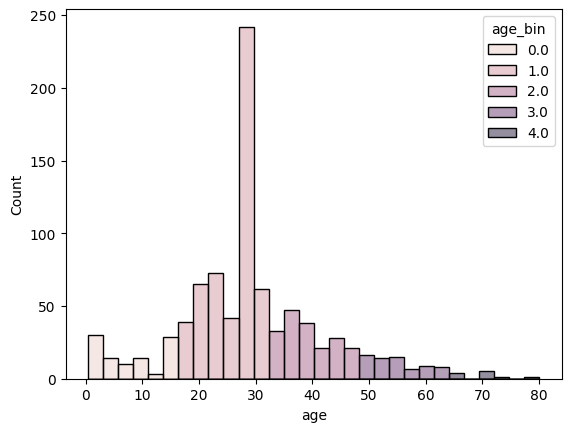

In [75]:
sns.histplot(df,x='age', hue = 'age_bin')

In [76]:
# pandas method for manual binning
df['age_bin'] = pd.cut(df['age'], bins=3, labels=[0,1,2])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_bin
0,0,3,male,22.0,1,0,22.0,S,Third,man,True,NaN,Southampton,no,False,0
1,1,1,female,38.0,1,0,38.0,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,female,26.0,0,0,26.0,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,1,0,35.0,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,male,35.0,0,0,35.0,S,Third,man,True,NaN,Southampton,no,True,1


<Axes: xlabel='age', ylabel='Count'>

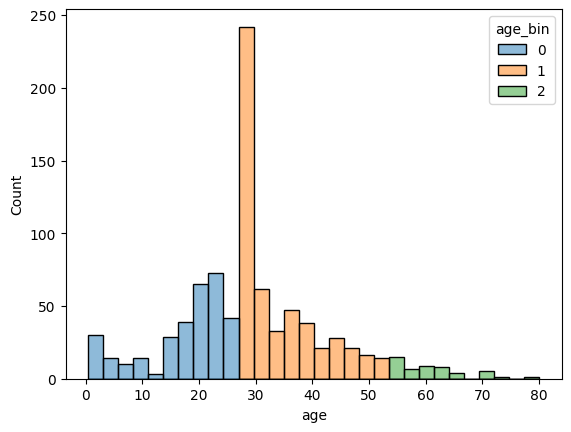

In [77]:
sns.histplot(df, x= 'age', hue='age_bin')

<Axes: xlabel='age', ylabel='Count'>

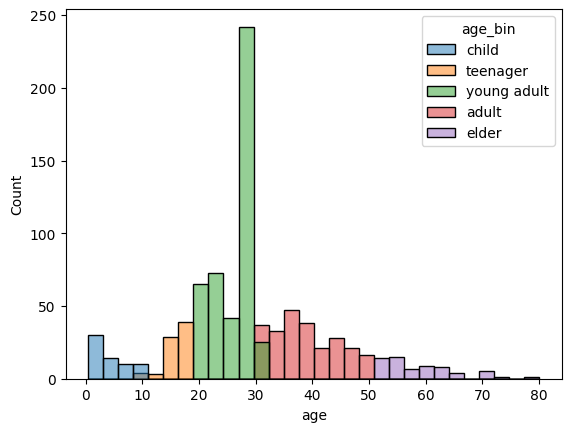

In [78]:
# define the bins
bins = [0, 10, 18, 30, 50, 80]
labels = ['child', 'teenager', 'young adult', 'adult', 'elder']

# use pd.cut function can attribute the values into its specific bins
df['age_bin'] =  pd.cut(df['age'], bins=bins, labels=labels)
sns.histplot(df, x='age', hue='age_bin')


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define labels only
labels = ['child', 'teenager', 'young adult', 'adult', 'elder']

# Use qcut to divide the data into 5 equal-frequency bins
df['age_bin'] = pd.qcut(df['age'], q=5, labels=labels, duplicates='drop')

# Plot the histogram
sns.histplot(data=df, x='age', hue='age_bin')
plt.show()